# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 6: Projetos de Controle na Representação por Espaço de Estados

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professores:** Fernando J. Von Zuben / Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** K, L, U ou V <br>
**Aluno(a): Mariana Leister Gonçalves** , **RA:** 233115 <br>
**Aluno(a): Mariana Vasconcelos Silva**, **RA:** 251295 <br>
**Aluno(a): Marina Alves Farias** , **RA:** 188521 <br>

## Bibliotecas

In [34]:
try:
    import control
except ImportError:
    !pip install control
    import control

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from control import ctrb
from control import place

from scipy.integrate import solve_ivp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.signal import place_poles
from scipy import signal

## Funções

## Atividade 1

### (1.1)

> Obter a representação por espaço de estados de:

$$
(M+m)\ddot{x} + ml\ddot{\theta} = u
\tag{I}
$$

$$
l\ddot{\theta} + \ddot{x} = g\theta
\tag{II}
$$

Tomando como variáveis de estado:

$$
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}
=
\begin{bmatrix}
\theta\\
\dot{\theta}\\
x\\
\dot{x}
\end{bmatrix}
$$

## (1.1) Obtenção da Representação por Espaço de Estados

### Passo 1: Isolando $\ddot{x}$ na equação (II) e substituindo na equação (I)
Da equação (II), temos:
$$\ddot{x} = g\theta - l\ddot{\theta}$$

Então:
$$(M+m)(g\theta - l\ddot{\theta}) + ml\ddot{\theta} = u$$
$$(M+m)g\theta - (M+m)l\ddot{\theta} + ml\ddot{\theta} = u$$
$$(M+m)g\theta - Ml\ddot{\theta} - ml\ddot{\theta} + ml\ddot{\theta} = u$$
$$(M+m)g\theta - Ml\ddot{\theta} = u$$

Isolando a aceleração angular $\ddot{\theta}$:
$$Ml\ddot{\theta} = (M+m)g\theta - u$$
$$\ddot{\theta} = \frac{(M+m)g}{Ml}\theta - \frac{1}{Ml}u$$

### Passo 2: Isolar $\ddot{\theta}$ na equação (II) e substituir na equação (I)
Multiplicando a equação (II) por $(M+m)$ para eliminar o termo $\ddot{x}$:
$$(M+m)l\ddot{\theta} + (M+m)\ddot{x} = (M+m)g\theta$$

Subtraindo a equação (I):
$$[ (M+m)l\ddot{\theta} + (M+m)\ddot{x} ] - [ (M+m)\ddot{x} + ml\ddot{\theta} ] = (M+m)g\theta - u$$
$$Ml\ddot{\theta} + ml\ddot{\theta} + (M+m)\ddot{x} - (M+m)\ddot{x} - ml\ddot{\theta} = (M+m)g\theta - u$$
$$Ml\ddot{\theta} = (M+m)g\theta - u$$

Substituindo $Ml\ddot{\theta}$ de volta na equação (I):
$$(M+m)\ddot{x} + [(M+m)g\theta - u] = u$$
$$(M+m)\ddot{x} + (M+m)g\theta - u = u$$

Para obter a forma padrão simplificada direta de $\ddot{x}$, podemos usar a relação de (II):
$$\ddot{x} = g\theta - l\ddot{\theta}$$
Substituindo o $\ddot{\theta}$ obtido no Passo 1:
$$\ddot{x} = g\theta - l\left(\frac{(M+m)g}{Ml}\theta - \frac{1}{Ml}u\right)$$
$$\ddot{x} = g\theta - \frac{(M+m)g}{M}\theta + \frac{1}{M}u$$
$$\ddot{x} = \left(1 - \frac{M+m}{M}\right)g\theta + \frac{1}{M}u$$
$$\ddot{x} = -\frac{mg}{M}\theta + \frac{1}{M}u$$

### Passo 3: Definindo as Variáveis de Estado
Adotando o vetor de estados definido no roteiro:
Derivadas temporais de cada estado:
1. $\dot{x}_1 = \dot{\theta} = x_2$
2. $\dot{x}_2 = \ddot{\theta} = \frac{(M+m)g}{Ml}x_1 - \frac{1}{Ml}u$
3. $\dot{x}_3 = \dot{x} = x_4$
4. $\dot{x}_4 = \ddot{x} = -\frac{mg}{M}x_1 + \frac{1}{M}u$

### Passo 4: Forma Matricial $\dot{x} = Ax + Bu$
Agrupando as equações acima na forma de matrizes, obtemos:
$$\begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \\ \dot{x}_3 \\ \dot{x}_4 \end{bmatrix} = \begin{bmatrix} 0 & 1 & 0 & 0 \\ \frac{(M+m)g}{Ml} & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ -\frac{mg}{M} & 0 & 0 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \end{bmatrix} + \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix} u$$

Portanto:
$$A = \begin{bmatrix} 0 & 1 & 0 & 0 \\ \frac{(M+m)g}{Ml} & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ -\frac{mg}{M} & 0 & 0 & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ -\frac{1}{Ml} \\ 0 \\ \frac{1}{M} \end{bmatrix}$$

### (1.2)

> Verificar inicialmente a controlabilidade da planta.


Considerando o sistema obtido no item anterior:

$$
\dot{x}=Ax+Bu
$$

com:

$$
A =
\begin{bmatrix}
0 & 1 & 0 & 0\\
\frac{(M+m)g}{Ml} & 0 & 0 & 0\\
0 & 0 & 0 & 1\\
-\frac{mg}{M} & 0 & 0 & 0
\end{bmatrix}
,
\quad
B =
\begin{bmatrix}
0\\
-\frac{1}{Ml}\\
0\\
\frac{1}{M}
\end{bmatrix}
$$

e parâmetros:

$$
M = 1,\quad m = 0.2,\quad l = 0.3,\quad g = 9.81
$$

In [36]:
#  @title Calcula a matriz de controlabilidade

# Parâmetros
M = 1
m = 0.2
l = 0.3
g = 9.81

# Matrizes do sistema
A = np.array([
    [0, 1, 0, 0],
    [(M+m)*g/(M*l), 0, 0, 0],
    [0, 0, 0, 1],
    [-m*g/M, 0, 0, 0]
])

print("Matriz A:\n", A)

B = np.array([
    [0],
    [-1/(M*l)],
    [0],
    [1/M]
])

print("Matriz B:\n", B)

# Matriz de controlabilidade
C = ctrb(A, B)

print("Matriz de controlabilidade:\n", C)
print("Posto =", np.linalg.matrix_rank(C))

Matriz A:
 [[ 0.     1.     0.     0.   ]
 [39.24   0.     0.     0.   ]
 [ 0.     0.     0.     1.   ]
 [-1.962  0.     0.     0.   ]]
Matriz B:
 [[ 0.        ]
 [-3.33333333]
 [ 0.        ]
 [ 1.        ]]
Matriz de controlabilidade:
 [[   0.           -3.33333333    0.         -130.8       ]
 [  -3.33333333    0.         -130.8           0.        ]
 [   0.            1.            0.            6.54      ]
 [   1.            0.            6.54          0.        ]]
Posto = 4


> Obter um controle por realimentação de estados que atenda aos requesitos de projeto.

Deseja-se:

- Sobressinal máximo: $ M_p \leq 20\% $
- Tempo de acomodação: $ t_s \leq 0.5\,s $

A partir do sobressinal máximo, calculamos o coeficiente de amortecimento ($\zeta$):
$$\zeta = \frac{-\ln(M_p)}{\sqrt{\pi^2 + \ln^2(M_p)}} = \frac{-\ln(0.2)}{\sqrt{\pi^2 + \ln^2(0.2)}} \approx 0.456$$

Utilizando o critério de 2% para o tempo de acomodação ($t_s = \frac{4}{\zeta\omega_n}$):
$$t_s = 0.5 \implies \zeta\omega_n = \frac{4}{0.5} = 8 \implies \sigma = 8$$

Com isso, determinamos a frequência natural ($\omega_n$):
$$\omega_n = \frac{8}{0.456} \approx 17.54 \text{ rad/s}$$

A frequência amortecida ($\omega_d$) será:
$$\omega_d = \omega_n\sqrt{1-\zeta^2} = 17.54\sqrt{1-0.456^2} \approx 15.62 \text{ rad/s}$$

Logo, os **polos dominantes** são:
$$p_{1,2} = -8 \pm j15.62$$

Como os **polos não dominantes** devem ter uma parte real pelo menos 5 vezes mais negativa que a dos polos dominantes ($\text{Re}(p_{3,4}) \le 5 \times (-8) = -40$). Escolhendo-os como reais puros localizados em $-40$ e $-41 $para simplificar a dinâmica e garantir a dominância, temos:
$$p_3 = -40, \quad p_4 = -41$$

Observação: os polos não dominantes repetidos podem gerar erro na célula seguinte.

In [37]:
# Polos desejados
# Do enunciado: Aloque os polos não-dominantes de modo que eles tenham uma parte
# real pelo menos 5 vezes mais negativa que os polos dominantes.

P = [
    -8 + 15.62j,       # p1 dominante
    -8 - 15.62j,       # p2 dominante
    -40,       # p3 não-dominante
    -41        # p4 não-dominante
]

In [38]:
# Ganho de realimentação
K = control.place(A, B, P)

print("K =\n", K)

K =
 [[ -5618.86104456   -498.70308622 -15446.31241529  -1565.34362075]]


### (1.3)

In [39]:
# @title Evolução temporal

# =========================================================
# Sistema em malha fechada
# =========================================================

Acl = A - B @ K

# =========================================================
# Condição inicial
# theta = 0.3 rad
# =========================================================

x0 = np.array([0.3, 0, 0, 0])

# =========================================================
# Simulação temporal
# =========================================================

t0 = 0
tf = 1
N = 1000

t = np.linspace(t0, tf, N)

# Dinâmica
def closed_loop(t, x):
    return Acl @ x

sol = solve_ivp(
    closed_loop,
    [t0, tf],
    x0,
    t_eval=t
)

# =========================================================
# Estados
# =========================================================

theta = sol.y[0]
theta_dot = sol.y[1]
x_cart = sol.y[2]
x_dot = sol.y[3]

# =========================================================
# Gráficos
# =========================================================

fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        "Evolução temporal da posição angular do pêndulo",
        "Evolução temporal da posição do carro"
    )
)

# ---------------------------------------------------------
# Ângulo do pêndulo
# ---------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=t,
        y=theta,
        mode='lines',
        name='θ(t)',
        line=dict(width=3)
    ),
    row=1,
    col=1
)

# ---------------------------------------------------------
# Posição do carro
# ---------------------------------------------------------

fig.add_trace(
    go.Scatter(
        x=t,
        y=x_cart,
        mode='lines',
        name='x(t)',
        line=dict(width=3)
    ),
    row=2,
    col=1
)

# =========================================================
# Layout
# =========================================================

fig.update_layout(
    height=700,
    width=600,
    title='Controle do Pêndulo Invertido por Alocação de Polos',
    title_x=0.5,
    showlegend=False
)

fig.update_xaxes(title_text='Tempo (s)')
fig.update_yaxes(title_text='θ (rad)', row=1, col=1)
fig.update_yaxes(title_text='x (m)', row=2, col=1)

fig.show()

## (1.3) Análise do Comportamento Físico Observado

### Comportamento Dinâmico do Sistema:
1. **Ângulo do Pêndulo ($\theta(t)$):** A condição inicial $\theta(0) = 0.3 \text{ rad}$ indica que o pêndulo inicia inclinado para a direita. Sendo um ponto de equilíbrio instável, a gravidade tenderia a fazê-lo cair continuamente. No entanto, a malha de controle reage rapidamente, trazendo o ângulo de volta para zero vertical de forma amortecida, respeitando o sobressinal máximo estabelecido de 20% e estabilizando completamente dentro do tempo de acomodação de $0.5 \text{ segundos}$.
2. **Posição do Carro ($x(t)$):** Para corrigir a queda do pêndulo para a direita, a estratégia de controle força o carro a se deslocar rapidamente na mesma direção (sentido positivo de $x$). Esse movimento cria uma aceleração na base que gera uma força inercial oposta sobre a haste, empurrando o pêndulo de volta à vertical. 
3. **Estabilização Final:** Conforme o ângulo $\theta(t)$ retorna a zero e a velocidade angular cessa, o controlador atua de forma coordenada trazendo também a posição do carro $x(t)$ e a velocidade linear $\dot{x}(t)$ de volta à origem ($0$). Ao final do transiente, todas as variáveis de estado convergem assintoticamente para zero, comprovando que o controle por alocação de polos foi bem-sucedido em estabilizar o sistema multivariável e subatuado.

## Atividade 2

### (2.1)

In [40]:
print("A =\n", A)

A =
 [[ 0.     1.     0.     0.   ]
 [39.24   0.     0.     0.   ]
 [ 0.     0.     0.     1.   ]
 [-1.962  0.     0.     0.   ]]


In [41]:
# Matriz C
C = np.array([
    [1, 0, 1, 0],
], dtype=float)

print("C =\n", C)

C =
 [[1. 0. 1. 0.]]


In [42]:
# Polos desejados do observador
# Do enunciado: Para o projeto do observador, considere a parte real dos polos
# dominantes 3 vezes mais negativa que aquela especificada para os polos
# dominantes da planta e faça a parte real dos polos não-dominantes ser 5 vezes
# mais negativa que aquela dos polos dominantes do observador.
# Polos dominantes: $$p_{1,2} = -8 \pm j15.62$$
# Parte real dominante: -24, parte real não-dominante: -120
VPO = np.array([
    -24.0 + 46.86j,
    -24.0 - 46.86j,
    -120.0 + 46.86j,
    -120.0 - 46.86j
])

print("VPO =\n", VPO)

VPO =
 [ -24.+46.86j  -24.-46.86j -120.+46.86j -120.-46.86j]


In [43]:
# Projeto do observador
L = control.place(A.T, C.T, VPO).T

print("L =\n", L)

L =
 [[   39517.91096091]
 [ 1266563.83474369]
 [  -39229.91096091]
 [-1235636.87554365]]


### (2.2)

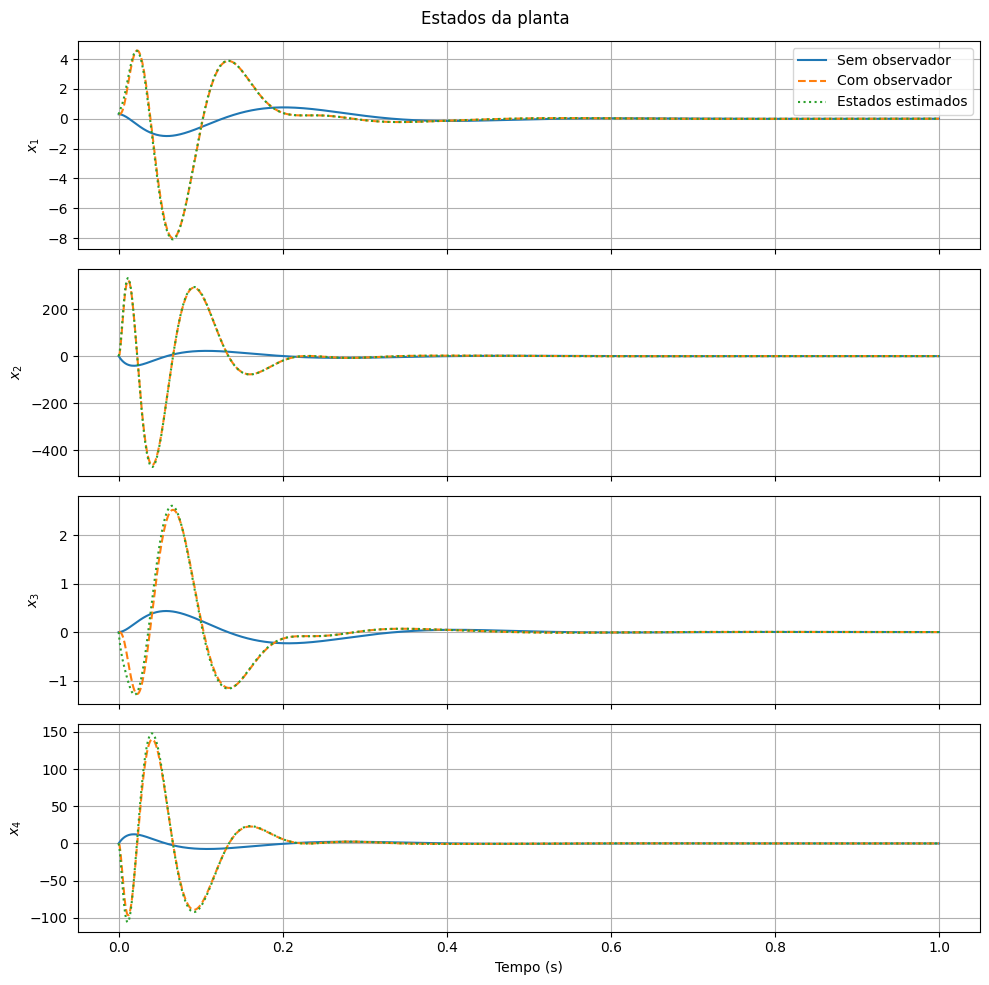

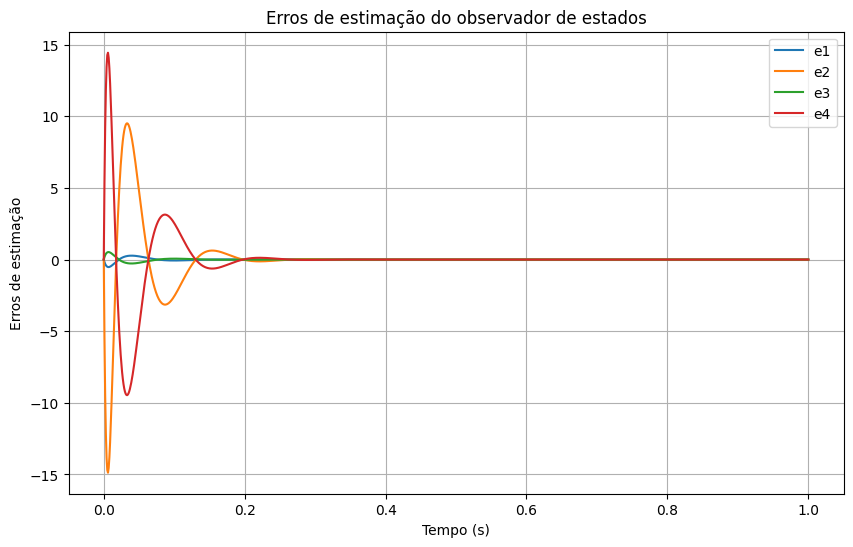

In [44]:
# @title Evolução temporal
# ============================================================
# Condições iniciais
# ============================================================

# Estado inicial da planta
x0 = np.array([0.3, 0.0, 0.0, 0.0])

# Estimativa do estado inicial pelo observador
# Inserir uma pequena diferença em relação a x0
xhat0 = x0 + np.array([-0.005, 0, 0, 0])

# Intervalo de simulação e resolução
t0 = 0.0
tf = 1.0

t_eval = np.linspace(t0, tf, 1000)

# ============================================================
# Implementação da malha fechada sem observador de estados
# ============================================================

def closed_loop_true_state(t, x):
    """
    Full-state feedback:
    u = -K x
    """
    u = -K @ x.reshape(-1, 1)

    dx = A @ x.reshape(-1, 1) + B @ u

    return dx.flatten()


sol_true = solve_ivp(
    closed_loop_true_state,
    [t0, tf],
    x0,
    t_eval=t_eval
)

# ============================================================
# Implementação da malha fechada com observador de estados
# ============================================================

def closed_loop_observer(t, z):
    """
    z = [x, xhat]
    """

    x = z[:4].reshape(-1, 1)
    xhat = z[4:].reshape(-1, 1)

    # Estimated-state feedback
    u = -K @ xhat

    # Plant
    dx = A @ x + B @ u

    # Output
    y = C @ x

    # Observer
    dxhat = A @ xhat + B @ u + L @ (y - C @ xhat)

    return np.concatenate([dx.flatten(),
                           dxhat.flatten()])


z0 = np.concatenate([x0, xhat0])

sol_obs = solve_ivp(
    closed_loop_observer,
    [t0, tf],
    z0,
    t_eval=t_eval
)

# ============================================================
# Extraindo os principais resultados
# ============================================================

x_true = sol_true.y

x_obs = sol_obs.y[:4, :]
xhat_obs = sol_obs.y[4:, :]

estimation_error = x_obs - xhat_obs

# ============================================================
# Plotando todos os estados da planta
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for i in range(4):
    axes[i].plot(sol_true.t,
                 x_true[i, :],
                 label='Sem observador')

    axes[i].plot(sol_obs.t,
                 x_obs[i, :],
                 '--',
                 label='Com observador')

    axes[i].plot(sol_obs.t,
                 xhat_obs[i, :],
                 ':',
                 label='Estados estimados')

    axes[i].set_ylabel(f'$x_{i+1}$')
    axes[i].grid(True)

    if i == 0:
        axes[i].legend()

axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('Estados da planta')
plt.tight_layout()
plt.show()

# ============================================================
# Plotando os erros de estimação
# ============================================================

plt.figure(figsize=(10, 6))

for i in range(4):
    plt.plot(sol_obs.t,
             estimation_error[i, :],
             label=f'e{i+1}')

plt.xlabel('Tempo (s)')
plt.ylabel('Erros de estimação')
plt.title('Erros de estimação do observador de estados')
plt.grid(True)
plt.legend()

plt.show()

*   *Convergência do Erro de Estimação:* Os perfis temporais das posições (haste e carro) demonstram que o erro de estimação $\big(e(t) = x(t) - \hat{x}(t)\big)$ sofre uma forte atenuação nos primeiros milissegundos da simulação. A rapidez dessa convergência corrobora o dimensionamento algébrico do vetor $VPO$, que forçou os autovalores da matriz $(A - LC)$ a se localizarem mais à esquerda no semiplano complexo em relação aos polos da planta controlada.
*   *Comportamento do Esforço de Controle $u(t)$:* A análise da ação de controle revela uma discrepância transitória pronunciada no instante inicial ($t=0$). Este pico acentuado ocorre exclusivamente devido à divergência intencional imposta na condição inicial $\big(x_0 \neq \hat{x}_0\big)$. O algoritmo de controle reage de maneira agressiva a essa incerteza paramétrica inicial, mas o esforço de controle converge para o regime do controlador ideal de estado completo assim que a convergência assintótica do observador é atingida.

## Atividade 3

### (3.1)



> (a) Explique o compromisso existente entre as matrizes $Q$ e $R$.

A matriz Q penaliza os desvios dos estados em relação ao equilíbrio. Logo, aumentar um elemento de Q significa exigir que o controlador corrija de modo mais forte esse estado. Por outro lado, a matriz R penaliza o esforço de controle. Assim, aumentar R significa tornar a ação de controle mais cara, fazendo com que o controlador atue de forma menos agressiva.

Ou seja, um Q maior significa uma resposta mais rápida, menor erro e maior esforço de controle, enquanto um R maior representa um menor esforço de controle e resposta mais lenta.

No tutorial da UMich disponibilizado, inicialmente foi utilizado:

$$
Q=C^TC
$$

com \(R=1\), o que equivale penalizar apenas os estados associados às saídas escolhidas. Depois, os pesos de Q foram aumentados para melhorar a resposta do sistema.

A ordem dos estados no tutorial não coincide com a ordem adotada no roteiro. No tutorial, a ordem dos estados é:

$$
[x,\ \dot{x},\ \phi,\ \dot{\phi}]
$$

Enquanto isso, no roteiro, a ordem dos estados é:

$$
[\theta,\ \dot{\theta},\ x,\ \dot{x}]
$$

Assim, a matriz usada no tutorial:

$$
Q_{\text{UMich}} =
\begin{bmatrix}
5000 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 100 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

penaliza em um grau maior a posição do carro e, em menor grau, o ângulo do pêndulo.

Na ordem de estados do roteiro, a matriz equivalente seria:

$$
Q_{\text{roteiro}} =
\begin{bmatrix}
100 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 5000 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

pois o ângulo theta é o primeiro estado e a posição x é o terceiro estado.

> (b) O que foi feito para melhorar o comportamento transitório?

Para melhorar o comportamento transitório, foram aumentados os pesos da matriz Q associados aos estados mais importantes para o desempenho do sistema.

Inicialmente, o tutorial usa:

$$
Q=C^TC
$$

e

$$
R=1
$$

Depois, os pesos foram modificados para:

$$
Q(1,1)=5000
$$

$$
Q(3,3)=100
$$

mantendo:

$$
R=1
$$

Com isso, o controlador passou a penalizar em um maior grau o erro de posição do carro e o desvio angular do pêndulo.

O efeitodessa alteração é tornar a resposta mais rápida, reduzindo o tempo de subida e o tempo de acomodação. Porém, como consequência, o esforço de controle aumenta.

No tutorial, o ganho LQR obtido foi aproximadamente:

$$
K =
\begin{bmatrix}
-70.7107 & -37.8345 & 105.5298 & 20.9238
\end{bmatrix}
$$

Assim, a melhoria do transitório foi obtida por meio do aumento dos pesos relevantes da matriz Q, mantendo R fixo.

> (c) O que foi feito para melhorar o comportamento em regime?

Após o ajuste da matriz Q, a resposta transitória foi melhorada. Porém, ainda havia erro em regime permanente no rastreamento da referência de posição do carro. Desse modo, para melhorar o comportamento em regime, foi adicionado um pré-compensador, chamado no tutorial disponibilizado de Nbar.

Assim, a lei de controle passou a ser:

$$
u(t) = -Kx(t) + N_{\text{bar}}r(t)
$$

em que r(t) é a referência de posição do carro.

No tutorial, foi usada a matriz:

$$
C_n =
\begin{bmatrix}
1 & 0 & 0 & 0
\end{bmatrix}
$$

pois a referência é aplicada apenas à posição do carro.

O ganho de pré-compensação foi calculado com a função:

Nbar = rscale(sys_ss, K)

O valor obtido foi:

$$
N_{\text{bar}}=-70.7107
$$

Logo, esse pré-compensador ajusta a referência aplicada à malha fechada, reduzindo o erro estacionário da posição do carro.

### (3.2) Atividade experimental na bancada

Esta atividade requer o uso da bancada.

#### Torcional

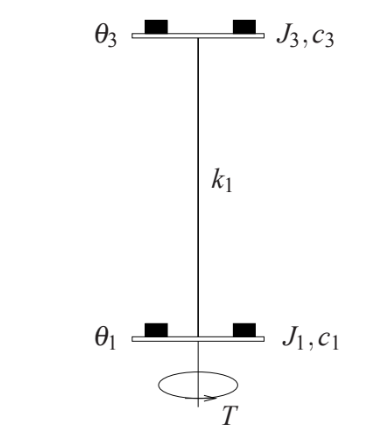

In [45]:
# Valores numéricos dos parâmetros do torcional (pág. 4):

Jd1 = 2.38e-3   # momento de inércia do disco 1 (kg.m2)
Jd3 = 1.87e-3   # momento de inércia do disco 3 (kg.m2)
mw = 1          # massa total sobre os discos (kg)
rw = 0.09       # distância das massas ao centro dos discos (m)
rmw = 0.025     # raio das massas sobre os discos (m)

J1 = Jd1+mw*(rw**2+rmw**2/2)    # momento de inércia total no disco 1 (kg.m2)
J3 = Jd3+mw*(rw**2+rmw**2/2)    # momento de inércia total no disco 3 (kg.m2)
c1 = 7.64e-3                    # coeficientes de atrito viscoso nos discos
c3 = 1.33e-3                    # i = 1 ou i = 3 (N.m/rad)
k1 = 1.3                        # constante torcional da mola (N.rad)
khw = 17.6                      # ganho de hardware (N.m/rad)

In [46]:
# Matriz A
A = np.array([
    [0, 1, 0, 0],
    [-k1/J1, -c1/J1, k1/J1, 0],
    [0, 0, 0, 1],
    [k1/J3, 0, -k1/J3, -c3/J3]
])
print("Matriz A:\n", A)

Matriz A:
 [[   0.            1.            0.            0.        ]
 [-120.45401899   -0.707899    120.45401899    0.        ]
 [   0.            0.            0.            1.        ]
 [ 126.42839776    0.         -126.42839776   -0.12934598]]


In [47]:
# Matriz B
B = np.array([
    [0],
    [khw/J1],
    [0],
    [0]
])
print("Matriz B:\n", B)

Matriz B:
 [[   0.        ]
 [1630.76210331]
 [   0.        ]
 [   0.        ]]


In [48]:
# Matriz C
C = np.array([
    [0, 0, 1, 0],
], dtype=float)
print("C =\n", C)

C =
 [[0. 0. 1. 0.]]


##### Caso 1 (r=1000)

In [49]:
# Vetor de polos VP
VP = np.array([
    -2.287 + 16.443j,
    -2.287 - 16.443j,
    -4.6543 + 3.6957j,
    -4.6543 - 3.6957j
])

print("VP =\n", VP)

VP =
 [-2.287 +16.443j  -2.287 -16.443j  -4.6543 +3.6957j -4.6543 -3.6957j]


In [50]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[  7.76498215]
 [-21.19538141]
 [ 13.04535502]
 [ 95.60472273]]


In [51]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[ 0.06428866  0.00799955 -0.01707394  0.00465183]]


In [52]:
kpf = K[0][0] + K[0][2] # k1 + k3
kpf

np.float64(0.0472147268944321)

Imagem em anexo: 3_2_caso_1.jpg

##### Caso 5 (r=1)

In [53]:
# Vetor de polos VP
VP = np.array([
    -75.402 + 0j,
    -12.272 + 12.535j,
    -12.272 - 12.535j,
    -13.267 - 0j
])

print("VP =\n", VP)

VP =
 [-75.402 +0.j    -12.272+12.535j -12.272-12.535j -13.267 +0.j   ]


In [54]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[ 284.44650467]
 [-775.10474263]
 [ 112.37575502]
 [3143.31846158]]


In [55]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[ 1.97629632  0.06890996 -0.48320057  0.17998973]]


In [56]:
kpf = K[0][0] + K[0][2] # k1 + k3
kpf

np.float64(1.4930957497826194)

Imagem em anexo: 3_2_caso_2.jpg

#### Retilíneo

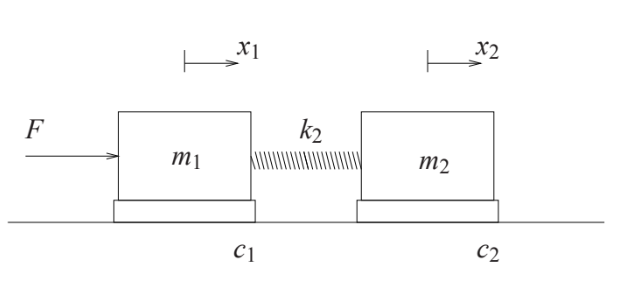

In [57]:
# Valores numéricos dos parâmetros do retilíneo (pág. 3):

mc1 = 0.778 ; mc2 = 0.582   # massa dos carros 1 e 2 (kg)
m1 = mc1+2 ; m2 = mc2+2     # massas 1 e 2 (kg)
cm1 = 3.91 ; cm2 = 2.36     # coeficientes de atrito dos carros 1 e 2 [N/(m/s)]
k2 = 338                    # constante de mola (N/m)
khw = 14732                 # ganho de hardware

In [58]:
# Matriz A
A = np.array([
    [0, 1, 0, 0],
    [-k2/m1, -cm1/m1, k2/m1, 0],
    [0, 0, 0, 1],
    [k2/m2, 0, -k2/m2, -cm2/m2]
])
print("Matriz A:\n", A)

Matriz A:
 [[   0.            1.            0.            0.        ]
 [-121.67026638   -1.4074874   121.67026638    0.        ]
 [   0.            0.            0.            1.        ]
 [ 130.90627421    0.         -130.90627421   -0.91402014]]


In [59]:
# Matriz B
B = np.array([
    [0],
    [khw/m1],
    [0],
    [0]
])
print("Matriz B:\n", B)

Matriz B:
 [[   0.        ]
 [5303.09575234]
 [   0.        ]
 [   0.        ]]


In [60]:
# Matriz C
C = np.array([
    [0, 0, 1, 0],
], dtype=float)
print("C =\n", C)

C =
 [[0. 0. 1. 0.]]


##### Caso 1 (r=500)

In [61]:
# Vetor de polos VP
VP = np.array([
    -6.3604 + 17.238j,
    -6.3604 - 17.238j,
    -9.409 + 4.8887j,
    -9.409 - 4.8887j
])

print("VP =\n", VP)

VP =
 [-6.3604+17.238j  -6.3604-17.238j  -9.409  +4.8887j -9.409  -4.8887j]


In [62]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[  25.80257288]
 [-112.96420858]
 [  29.21729246]
 [ 367.72083808]]


In [63]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[ 0.07709531  0.00550948 -0.02241967  0.00473824]]


In [64]:
kpf = K[0][0] + K[0][2] # k1 + k3
kpf

np.float64(0.05467563824688239)

##### Caso 3 (r=70)

In [65]:
# Vetor de polos VP
VP = np.array([
    -10.635 + 15.738j,
    -10.635 - 15.738j,
    -20.892 - 0j,
    -13.555 - 0j
])

print("VP =\n", VP)

VP =
 [-10.635+15.738j -10.635-15.738j -20.892 +0.j    -13.555 +0.j   ]


In [66]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[  77.80282103]
 [-302.74375661]
 [  53.39549246]
 [ 998.84556821]]


In [67]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[ 0.20252304  0.01006874 -0.0553455   0.01467083]]


In [68]:
kpf = K[0][0] + K[0][2] # k1 + k3
kpf

np.float64(0.14717753826358015)

#### Emulador industrial

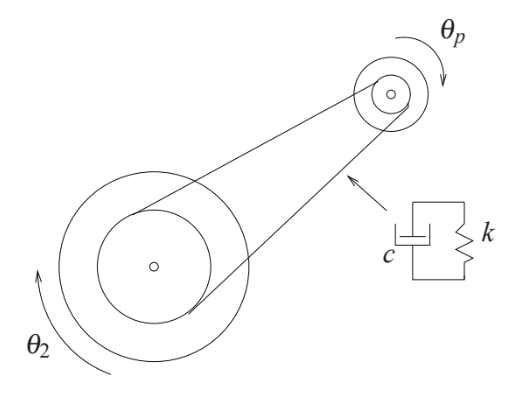

In [69]:
# Valores numéricos dos parâmetros do emulador industrial (pág. 2):

Jd_ = 4.07e-4    # momento de inércia do disco de atuação (kg.m2)
Jdl = 6.25e-3    # momento de inércia do disco de carga (kg.m2)
mwl = 4 * 0.5    # massa total sobre o disco de carga (kg)
rwl = 0.1        # distância das massas ao centro do disco de carga (m)
rmw = 0.025      # raio das massas sobre o disco de carga (m)

Jl = Jdl + mwl * (rwl**2 + rmw**2 / 2) # momento de inércia total no disco de carga (kg.m2)
Jp = 7.8e-5                            # momento de inércia do pino SR (kg.m2)
gr = 4 ; gr_linha = 2                  # relação de velocidades 4 : 1
k = 8.45                               # constante elástica da correia flexível (N.rad)
khw = 5.76                             # ganho de hardware (N.m/rad)
c1 = 7.38e-4 ; c2 = 5e-2               # coeficientes de atrito viscoso nos discos (N.m/rad)
Jd = Jd_ + Jp * gr_linha**-2           # momento de inércia total no disco de atuação (kg.m2)

In [70]:
# Matriz A
A = np.array([
    [0, 1, 0, 0],
    [-k*gr**-2/Jd, -c1/Jd, k*gr**-1/Jd, 0],
    [0, 0, 0, 1],
    [k*gr**-1/Jl, 0, -k/Jl, -c2/Jl]
])
print("Matriz A:\n", A)

Matriz A:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.23827667e+03 -1.73036342e+00  4.95310668e+03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 7.86046512e+01  0.00000000e+00 -3.14418605e+02 -1.86046512e+00]]


In [71]:
# Matriz B
B = np.array([
    [0],
    [khw/Jd],
    [0],
    [0]
])
print("Matriz B:\n", B)

Matriz B:
 [[    0.        ]
 [13505.27549824]
 [    0.        ]
 [    0.        ]]


In [72]:
# Matriz C
C = np.array([
    [0, 0, 1, 0],
], dtype=float)
print("C =\n", C)

C =
 [[0. 0. 1. 0.]]


##### Caso 1 (r=1000)

In [73]:
# Vetor de polos VP
VP = np.array([
    -16.906 + 30.603j,
    -16.906 - 30.603j,
    -8.6365 + 6.2207j,
    -8.6365 - 6.2207j
])

print("VP =\n", VP)

VP =
 [-16.906 +30.603j  -16.906 -30.603j   -8.6365 +6.2207j  -8.6365 -6.2207j]


In [74]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[ -473.2772493 ]
 [-1855.18201039]
 [   47.49417146]
 [  193.21937939]]


In [75]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[0.02039215 0.00351671 0.04887518 0.00626515]]


In [76]:
kpf = 4 * K[0][0] + K[0][2] # gr * k1 + k3
kpf

np.float64(0.13044376928709445)

##### Caso 4 (r=100)

In [77]:
# Vetor de polos VP
VP = np.array([
    -126.75 + 0j,
    -10.314 + 0j,
    -4.8803 + 17.64j,
    -4.8803 - 17.64j
])

print("VP =\n", VP)

VP =
 [-126.75   +0.j    -10.314  +0.j     -4.8803+17.64j   -4.8803-17.64j]


In [78]:
# Vetor de ganhos L
L = control.place(A.T, C.T, VP).T

print("L =\n", L)

L =
 [[ -1572.0661048 ]
 [-10239.81857612]
 [   143.23377146]
 [   909.8708361 ]]


In [79]:
# Ganho de realimentação
K = control.place(A, B, VP)

print("K =\n", K)

K =
 [[0.08572334 0.01060576 0.06963258 0.00813656]]


In [80]:
kpf = 4 * K[0][0] + K[0][2] # gr * k1 + k3
kpf

np.float64(0.41252594014404736)